In [1]:
import pandas as pd

data = pd.read_csv("athlete_events.csv")
regions = pd.read_csv("noc_regions.csv")

data.info()
data.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [2]:
winter = data[data["Season"] == "Winter"]
winter = winter.merge(regions, on="NOC", how="left")



In [3]:
cold_countries = [ "Norway", "Sweden", "Finland", "Denmark", "Iceland", 
                  "Canada", "Russia", "Estonia", "Latvia", "Lithuania", "Switzerland", "Austria",
                  "Germany", "Czech Republic", "Poland", "Slovakia", "Slovenia" ]

winter["Climate"] = winter["region"].apply(lambda x: "Cold" if x in cold_countries else "Warm")
medals = winter[winter["Medal"].notna()]

In [4]:
winter.groupby("Climate")["ID"].count()


Climate
Cold    25886
Warm    22678
Name: ID, dtype: int64

In [5]:
medals.groupby("Climate")["Medal"].count()

Climate
Cold    4160
Warm    1535
Name: Medal, dtype: int64

In [6]:
medals_per_athlete = (
    medals.groupby("Climate")["ID"].count() /
    winter.groupby("Climate")["ID"].count()
)
print(medals_per_athlete)

Climate
Cold    0.160705
Warm    0.067687
Name: ID, dtype: float64


In [7]:
medals.groupby("region")["Medal"].count().sort_values(ascending=False)


region
Russia            759
USA               635
Germany           630
Canada            611
Norway            443
Sweden            428
Finland           426
Austria           280
Switzerland       275
Czech Republic    231
Italy             191
France            150
Netherlands       122
South Korea        86
UK                 83
China              80
Japan              63
Poland             27
Slovenia           18
Australia          16
Latvia             15
Belarus            15
Belgium            13
Hungary            12
Croatia            11
Ukraine            11
Liechtenstein       9
India               7
Kazakhstan          7
Estonia             7
Serbia              7
Bulgaria            6
Denmark             5
Slovakia            5
Luxembourg          2
North Korea         2
Romania             2
Spain               2
Nepal               1
New Zealand         1
Uzbekistan          1
Name: Medal, dtype: int64

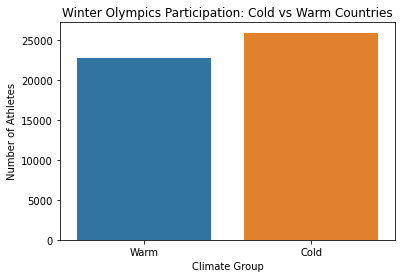

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(
    data=winter,
    x="Climate",
    y="ID",
    estimator=len,
    palette=["#1f77b4", "#ff7f0e"]
)

plt.title("Winter Olympics Participation: Cold vs Warm Countries")
plt.ylabel("Number of Athletes")
plt.xlabel("Climate Group")
plt.show()



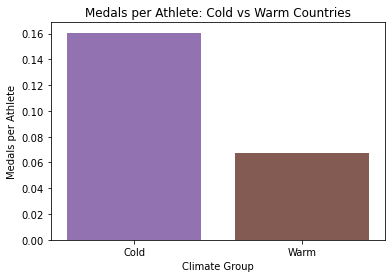

In [9]:
participation = winter.groupby("Climate")["ID"].count()
medal_counts = medals.groupby("Climate")["Medal"].count()

medals_per_athlete = medal_counts / participation
medals_per_athlete

plt.figure(figsize=(6,4))
sns.barplot(
    x=medals_per_athlete.index,
    y=medals_per_athlete.values,
    palette=["#9467bd", "#8c564b"]
)

plt.title("Medals per Athlete: Cold vs Warm Countries")
plt.ylabel("Medals per Athlete")
plt.xlabel("Climate Group")
plt.show()


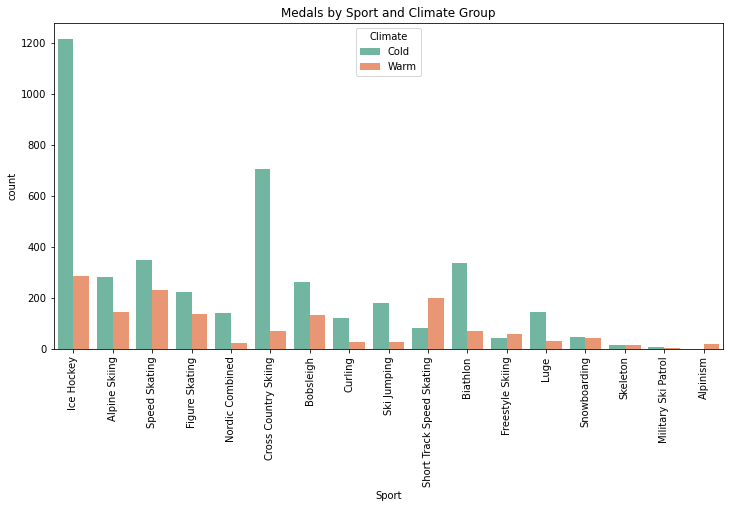

In [10]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=medals,
    x="Sport",
    hue="Climate",
    palette="Set2"
)

plt.xticks(rotation=90)
plt.title("Medals by Sport and Climate Group")
plt.show()


In [11]:
# This bar chart shows that mostly on the all of the types of sport in the WOG dominate athlets from the Cold countries,
# There are some exaptions, like "Short Track Speed Skating" or "Alpinism", 
#Overall, the visualization provides clear descriptive evidence supporting Hypothesis 3.

In [13]:
cold_medals = 4160
warm_medals = 1535


cold_athletes = 25886
warm_athletes = 22678

# Check the hypothesis: nothern countries have more medals than warm countries 
# on the Winter Olympic Games using Z-statistic test, h0 - they have the same result, h1 - nothern countries have more.
# p-value less than 0.05, so, we're rejecting null hypo. It' one more evidence for first hypothesis.

from statsmodels.stats.proportion import proportions_ztest

# successes (medals)
successes = [cold_medals, warm_medals]

# observations (athletes)
nobs = [cold_athletes, warm_athletes]

z_stat, p_value = proportions_ztest(successes, nobs, alternative='larger')

print("Z-statistic:", z_stat)
print("P-value:", p_value)


Z-statistic: 31.78630052866227
P-value: 5.005206976430271e-222


In [ ]:
#Second hypothesis, we checked via confidence interval with 95% confidence. Warm-climate athletes participate less
# frequently in WOG than athlets from nothern countries. h0 - thay have equal proportions of athlets, h1 - result is different.
# In cofidenence interval we positive result, so, we are rejecting the null hypo. It's prove for 2 hypothesis


import statsmodels.api as sm
import numpy as np

cold_athletes = 25886
warm_athletes = 22678

total = cold_athletes + warm_athletes

p_cold = cold_athletes / total
p_warm = warm_athletes / total

diff = p_cold - p_warm

# standard error
se = np.sqrt(p_cold*(1-p_cold)/total + p_warm*(1-p_warm)/total)

z = 1.96
lower = diff - z*se
upper = diff + z*se

print("Difference in proportions:", diff)
print("95% Confidence Interval:", (lower, upper))


In [15]:
# Create country-level summary
df_country = winter.groupby("region").agg(
    athletes=("ID", "count"),
    medals=("Medal", lambda x: x.notna().sum())
).reset_index()


df_country["medals_per_athlete"] = df_country["medals"] / df_country["athletes"]


df_country = df_country.merge(
    winter[["region", "Climate"]].drop_duplicates(),
    on="region",
    how="left"
)


df_country["climate_num"] = df_country["Climate"].apply(lambda x: 1 if x == "Cold" else 0)

df_country.head()


,region,athletes,medals,medals_per_athlete,Climate,climate_num
0,Albania,7,0,0.0,Warm,0
1,Algeria,12,0,0.0,Warm,0
2,American Samoa,2,0,0.0,Warm,0
3,Andorra,116,0,0.0,Warm,0
4,Argentina,384,0,0.0,Warm,0


In [16]:
df_country[['athletes', 'medals']].corr()
# There is huge correlation between athlets and medals, what means countries that send more athletes won more medals(r ≈ 0.90). 
# This indicates that participation size is one of the strongest predictors of medal success


,athletes,medals
athletes,1.000000,0.903398
medals,0.903398,1.000000


In [17]:
df_country[['climate_num', 'medals_per_athlete']].corr()

## There is strong positive correlation between climate and medals per athlete. 
# Cold countries tend to win more medals per athlete than warm countries.
# what indicates that climate play a big role in prediction as well

,climate_num,medals_per_athlete
climate_num,1.000000,0.516377
medals_per_athlete,0.516377,1.000000


In [18]:
import statsmodels.formula.api as smf

ols_model = smf.ols(
    formula="medals ~ athletes + climate_num",
    data=df_country
).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 medals   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     248.0
Date:                Sat, 21 Feb 2026   Prob (F-statistic):           4.28e-41
Time:                        15:56:06   Log-Likelihood:                -614.22
No. Observations:                 111   AIC:                             1234.
Df Residuals:                     108   BIC:                             1243.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     -20.1580      6.739     -2.991      

In [ ]:
# According to this result, we can create the formula for predicting result in medals using 2 indepent values 
# "athlets" and "climate". climate tent to be not so importynt as amount of athlets because p value is bigger than alfa
# Predicted medals = -20.1580 + 0.1512 ⋅ athletes + 34.5676 ⋅ climate_num
# The OLS regression model showed that the number of athletes a country sends is the strongest predictor of medal count 
# (β = 0.151, p < 0.001). Climate had a positive but statistically weaker effect (β = 34.57, p = 0.084), 
# indicating that cold countries tend to win more medals, but this effect becomes less significant once participation size 
# is included. The model explains 82.1% of the variance in medal counts (R² = 0.821), suggesting that 
# participation and climate together provide a strong predictive framework.

In [20]:
import statsmodels.api as sm
df_country["win_any"] = (df_country["medals"] > 0).astype(int)

logit_model = smf.glm(
    formula="win_any ~ athletes + climate_num",
    data=df_country,
    family=sm.families.Binomial()
).fit()

print(logit_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                win_any   No. Observations:                  111
Model:                            GLM   Df Residuals:                      108
Model Family:                Binomial   Df Model:                            2
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                    nan
Date:                Sat, 21 Feb 2026   Deviance:                          nan
Time:                        15:57:05   Pearson chi2:                     80.6
No. Iterations:                   100                                         
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -2.8743      0.495     -5.808      

In [ ]:
# the same climate has less p value that we dont have enough evidence that take it 
# into account and here will be formula - 2.87 + athlets*0.127 + climate * 0.45
# The logistic regression model showed that the number of athletes a country sends is a strong 
# and statistically significant predictor of whether it wins at least one medal (β = 0.0127, p < 0.001). 
# Climate, however, was not statistically significant (β = 0.45, p = 0.722), indicating that once participation 
# size is accounted for, climate does not meaningfully improve the prediction of winning any medal. 
# This suggests that participation is the dominant factor in determining whether a country wins at least one medal, 
# while climate plays a much smaller role in this binary outcome.”